# Synthetic game onboarding experiment

This self-contained notebook demonstrates the complete fixed-horizon workflow using deterministic **synthetic data**. Its outputs are illustrative and are not real-world evidence.

The estimand is always treatment minus control. Binary outcomes use the pooled score test and Newcombe hybrid Wilson interval. Session duration uses Welch inference. Holm adjustment controls family-wise error across the displayed metric family. The charts are authored with Plotly and stored as static PNG outputs so they render directly on GitHub.

In [1]:
import json

import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import JSON, Markdown, display
from plotly.subplots import make_subplots

from experimentation_toolkit import (
    Experiment,
    ExperimentReport,
    Metric,
    MetricType,
    adjust_p_values,
    analyze_continuous,
    analyze_proportion,
    check_sample_ratio_mismatch,
)

pio.templates.default = "plotly_white"
pio.renderers.default = "png"
pio.renderers["png"].width = 1_100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1.25
COLORS = {
    "control": "#3366CC",
    "treatment": "#E67300",
    "interval": "#284B63",
    "reference": "#666666",
}

## Synthetic data and analysis setup

The fixed seed makes the example reproducible. Assignment counts, binary outcomes, and session durations are generated once, analyzed through the public API, and assembled into one serializable report.

In [2]:
rng = np.random.default_rng(20260921)
control_size = 10_050
treatment_size = 9_950

srm = check_sample_ratio_mismatch(
    observed_counts={
        "existing onboarding": control_size,
        "new onboarding": treatment_size,
    },
    expected_proportions={
        "existing onboarding": 0.5,
        "new onboarding": 0.5,
    },
)

control_completion = rng.binomial(1, 0.62, control_size)
treatment_completion = rng.binomial(1, 0.645, treatment_size)
control_retention = rng.binomial(1, 0.31, control_size)
treatment_retention = rng.binomial(1, 0.318, treatment_size)
control_duration = np.maximum(
    rng.normal(34.0, 12.0, control_size),
    0.0,
)
treatment_duration = np.maximum(
    rng.normal(35.2, 13.5, treatment_size),
    0.0,
)

completion = analyze_proportion(
    control_successes=int(control_completion.sum()),
    control_total=control_size,
    treatment_successes=int(treatment_completion.sum()),
    treatment_total=treatment_size,
    metric_name="onboarding completion rate",
)
retention = analyze_proportion(
    control_successes=int(control_retention.sum()),
    control_total=control_size,
    treatment_successes=int(treatment_retention.sum()),
    treatment_total=treatment_size,
    metric_name="7-day retention",
)
duration = analyze_continuous(
    control=control_duration,
    treatment=treatment_duration,
    metric_name="session duration (minutes)",
)
analyses = (completion, retention, duration)
correction = adjust_p_values(
    (result.p_value for result in analyses if result.p_value is not None),
    method="holm",
    hypothesis_labels=tuple(result.metric_name or "unnamed" for result in analyses),
)

experiment = Experiment(
    name="Synthetic game onboarding redesign",
    control="existing onboarding",
    treatment="new onboarding",
    metrics=(
        Metric(
            name="onboarding completion rate",
            metric_type=MetricType.PROPORTION,
            primary=True,
        ),
        Metric(
            name="7-day retention",
            metric_type=MetricType.PROPORTION,
        ),
        Metric(
            name="session duration (minutes)",
            metric_type=MetricType.CONTINUOUS,
        ),
    ),
)
report = ExperimentReport(
    experiment=experiment,
    analyses=analyses,
    diagnostics=(srm,),
    multiple_testing=correction,
    metadata={
        "synthetic": True,
        "random_seed": 20260921,
    },
)

## 1. Assignment integrity

SRM is checked before metric interpretation. A failure suggests that observed assignment counts are inconsistent with the configured allocation. It does not identify the cause.

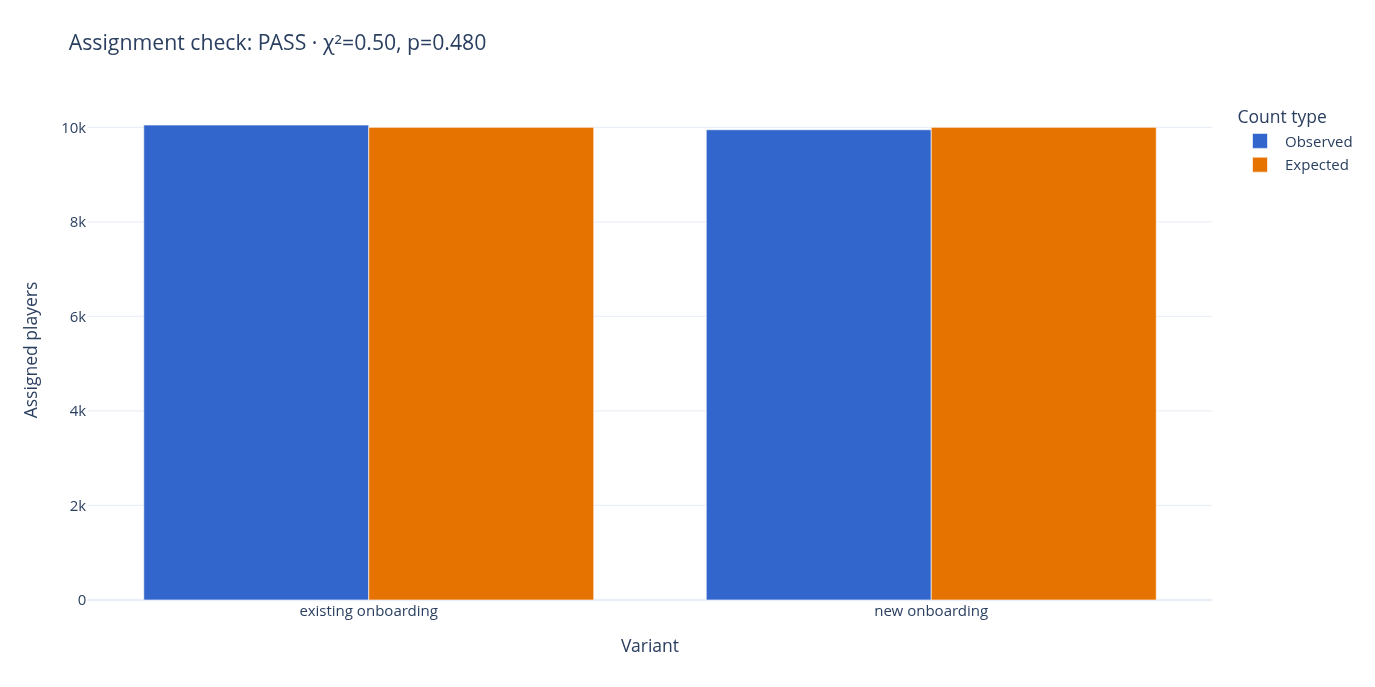

**Degrees of freedom:** 1
**Decision threshold:** 0.01
**Interpretation:** No sample ratio mismatch was detected at the selected threshold.

In [3]:
srm = report.diagnostics[0]
labels = list(srm.observed_counts)
observed = [srm.observed_counts[label] for label in labels]
expected = [srm.expected_counts[label] for label in labels]

fig = go.Figure()
fig.add_bar(
    name="Observed",
    x=labels,
    y=observed,
    marker_color=COLORS["control"],
    hovertemplate="%{x}<br>Observed: %{y:,.0f}<extra></extra>",
)
fig.add_bar(
    name="Expected",
    x=labels,
    y=expected,
    marker_color=COLORS["treatment"],
    hovertemplate="%{x}<br>Expected: %{y:,.0f}<extra></extra>",
)
fig.update_layout(
    barmode="group",
    title=(
        f"Assignment check: {srm.status} · χ²={srm.chi_square_statistic:.2f}, p={srm.p_value:.3f}"
    ),
    xaxis_title="Variant",
    yaxis_title="Assigned players",
    height=450,
    legend_title_text="Count type",
    margin={"l": 70, "r": 30, "t": 80, "b": 70},
)
fig.show()

display(
    Markdown(
        f"""**Degrees of freedom:** {srm.degrees_of_freedom}
**Decision threshold:** {srm.significance_level:g}
**Interpretation:** {srm.message}"""
    )
)

## 2. Effect estimates and uncertainty

Absolute effects remain on each metric's natural scale. The dashed line marks the point null. Confidence intervals quantify uncertainty; they do not determine practical importance.

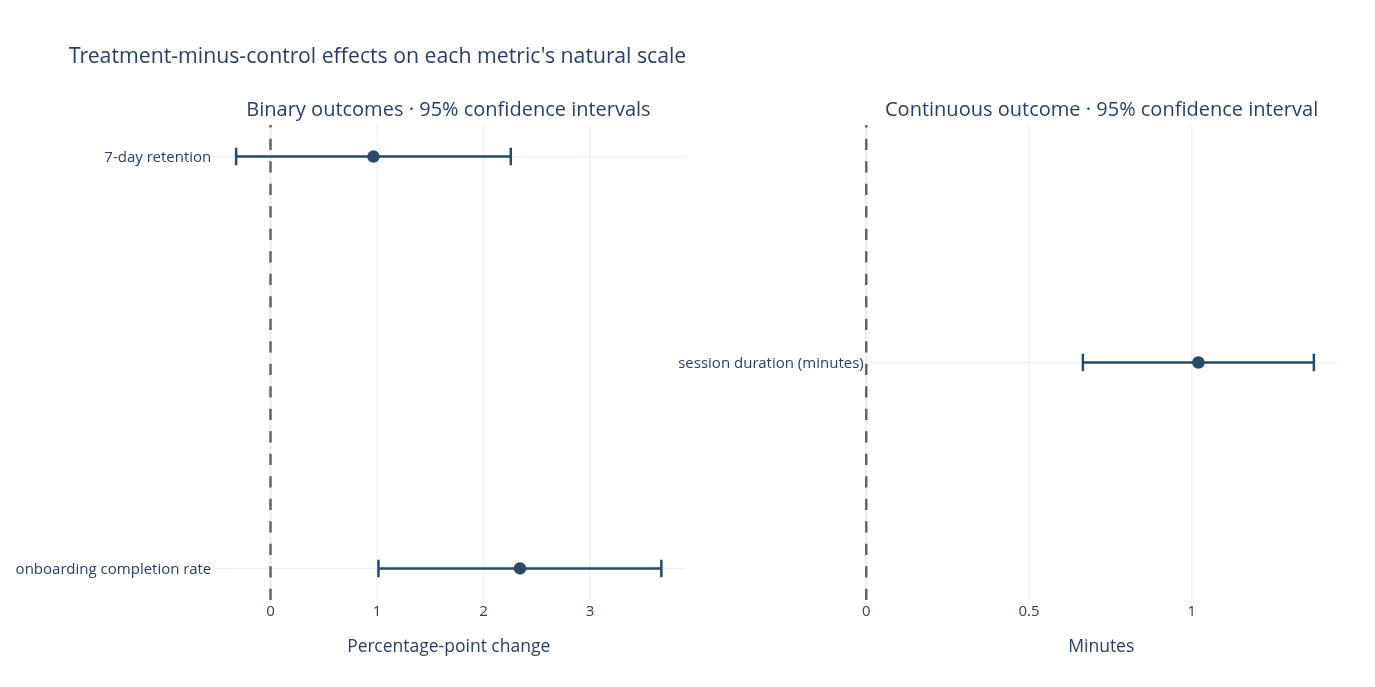

In [4]:
proportions = [item for item in report.analyses if item.metric_type is MetricType.PROPORTION]
continuous = [item for item in report.analyses if item.metric_type is MetricType.CONTINUOUS]

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Binary outcomes · 95% confidence intervals",
        "Continuous outcome · 95% confidence interval",
    ),
    horizontal_spacing=0.16,
)
panels = (
    (1, proportions, 100.0, "Percentage-point change"),
    (2, continuous, 1.0, "Minutes"),
)
for column, results, multiplier, unit in panels:
    effects = np.array([item.absolute_effect * multiplier for item in results])
    lower = np.array([item.confidence_interval.lower * multiplier for item in results])
    upper = np.array([item.confidence_interval.upper * multiplier for item in results])
    names = [item.metric_name for item in results]

    fig.add_trace(
        go.Scatter(
            x=effects,
            y=names,
            mode="markers",
            marker={
                "color": COLORS["interval"],
                "size": 10,
            },
            error_x={
                "type": "data",
                "symmetric": False,
                "array": upper - effects,
                "arrayminus": effects - lower,
                "thickness": 2,
                "width": 7,
                "color": COLORS["interval"],
            },
            customdata=np.column_stack((lower, upper)),
            hovertemplate=(
                "%{y}<br>Effect: %{x:.3f}<br>"
                "95% CI: [%{customdata[0]:.3f}, "
                "%{customdata[1]:.3f}]<extra></extra>"
            ),
            showlegend=False,
        ),
        row=1,
        col=column,
    )
    fig.add_vline(
        x=0.0,
        line_dash="dash",
        line_color=COLORS["reference"],
        row=1,
        col=column,
    )
    fig.update_xaxes(
        title_text=unit,
        row=1,
        col=column,
    )

fig.update_layout(
    title="Treatment-minus-control effects on each metric's natural scale",
    height=500,
    margin={"l": 80, "r": 30, "t": 100, "b": 70},
)
fig.show()

## 3. Multiplicity

The family contains the primary and secondary metrics shown here. Holm-adjusted p-values control the family-wise error rate. Adjustment does not turn statistical evidence into a business decision.

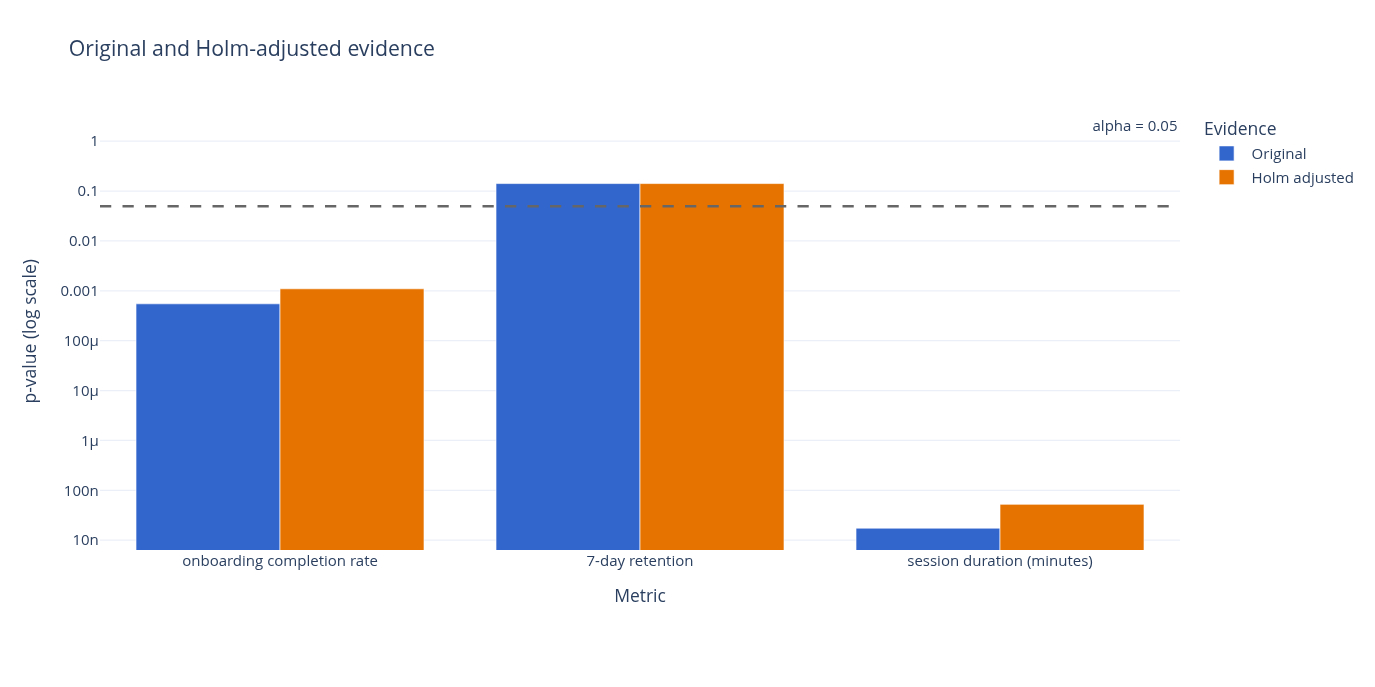

In [5]:
correction = report.multiple_testing
assert correction is not None

labels = list(correction.hypothesis_labels or ())
original = np.array(correction.original_p_values)
adjusted = np.array(correction.adjusted_p_values)

fig = go.Figure()
fig.add_bar(
    name="Original",
    x=labels,
    y=original,
    marker_color=COLORS["control"],
    hovertemplate="%{x}<br>Original p: %{y:.3g}<extra></extra>",
)
fig.add_bar(
    name="Holm adjusted",
    x=labels,
    y=adjusted,
    marker_color=COLORS["treatment"],
    hovertemplate="%{x}<br>Adjusted p: %{y:.3g}<extra></extra>",
)
fig.add_hline(
    y=correction.alpha,
    line_dash="dash",
    line_color=COLORS["reference"],
    annotation_text=f"alpha = {correction.alpha:g}",
    annotation_position="top right",
)
fig.update_yaxes(
    type="log",
    title_text="p-value (log scale)",
)
fig.update_layout(
    barmode="group",
    title="Original and Holm-adjusted evidence",
    xaxis_title="Metric",
    height=500,
    legend_title_text="Evidence",
    margin={"l": 80, "r": 40, "t": 90, "b": 110},
)
fig.show()

## 4. Structured report

All public results are immutable Pydantic models. Unbounded interval endpoints use `None` and serialize as JSON `null`; NaN and infinity are rejected.

In [6]:
payload = json.loads(report.model_dump_json())
display(
    JSON(
        {
            "experiment": payload["experiment"],
            "srm": payload["diagnostics"][0],
            "multiple_testing": payload["multiple_testing"],
        },
        expanded=False,
    )
)

json_length = len(report.model_dump_json())
print(
    f"Serialized report contains {len(payload['analyses'])} analyses "
    f"and {json_length} JSON characters."
)

<IPython.core.display.JSON object>

Serialized report contains 3 analyses and 4112 JSON characters.


## What these results mean

The interpretation below is generated from the computed report, so the narrative stays aligned with the estimates, intervals, SRM decision, and Holm-adjusted tests shown above.

In [7]:
completion, retention, duration = report.analyses
correction = report.multiple_testing
assert correction is not None

adjusted_by_metric = dict(
    zip(
        correction.hypothesis_labels or (),
        correction.adjusted_p_values,
        strict=True,
    )
)
rejected_by_metric = dict(
    zip(
        correction.hypothesis_labels or (),
        correction.rejected,
        strict=True,
    )
)

completion_ci = completion.confidence_interval
retention_ci = retention.confidence_interval
duration_ci = duration.confidence_interval
assert completion_ci.lower is not None
assert completion_ci.upper is not None
assert retention_ci.lower is not None
assert retention_ci.upper is not None
assert duration_ci.lower is not None
assert duration_ci.upper is not None

completion_name = completion.metric_name or "onboarding completion rate"
retention_name = retention.metric_name or "7-day retention"
duration_name = duration.metric_name or "session duration"

display(
    Markdown(
        f"""
1. **Assignment integrity passed the configured check.** The observed split was
   {srm.observed_counts["existing onboarding"]:,} control and
   {srm.observed_counts["new onboarding"]:,} treatment assignments. The SRM test gave
   p = {srm.p_value:.3f} at a {srm.significance_level:g} threshold. This means the
   observed imbalance is compatible with the planned 50/50 allocation; it does not
   prove that randomization or instrumentation was flawless.

2. **The primary completion metric increased in this synthetic sample.** The estimated
   treatment-minus-control change was {completion.absolute_effect * 100:.2f} percentage
   points, with a 95% confidence interval from
   {completion_ci.lower * 100:.2f} to {completion_ci.upper * 100:.2f} percentage points.
   Its Holm-adjusted p-value was {adjusted_by_metric[completion_name]:.4g}, so the null
   was {"rejected" if rejected_by_metric[completion_name] else "not rejected"} within
   the three-metric family at alpha = {correction.alpha:g}.

3. **The retention result is inconclusive at this precision.** The estimate was
   {retention.absolute_effect * 100:.2f} percentage points and its 95% confidence
   interval ran from {retention_ci.lower * 100:.2f} to
   {retention_ci.upper * 100:.2f} percentage points. The interval includes zero and
   the Holm-adjusted p-value was {adjusted_by_metric[retention_name]:.3f}; these data do
   not rule out either a small decrease or a small increase.

4. **Session duration increased statistically.** The estimated mean difference was
   {duration.absolute_effect:.2f} minutes, with a 95% Welch interval from
   {duration_ci.lower:.2f} to {duration_ci.upper:.2f} minutes. Its Holm-adjusted
   p-value was {adjusted_by_metric[duration_name]:.3g}. Whether extra session time is
   desirable depends on product goals and user experience; the test does not answer
   that business question.

5. **Multiplicity changes the evidence threshold, not the effect estimates.** Holm's
   procedure controls the family-wise error rate across the three displayed metrics.
   The point estimates and confidence intervals remain metric-specific, while the
   adjusted p-values govern the joint rejection decisions.

These results come from seeded synthetic data. They demonstrate how to read the report,
not whether an onboarding design should ship. A real decision would also need a
pre-specified analysis plan, data-quality review, practical effect thresholds, and
domain context.
"""
    )
)


1. **Assignment integrity passed the configured check.** The observed split was
   10,050 control and
   9,950 treatment assignments. The SRM test gave
   p = 0.480 at a 0.01 threshold. This means the
   observed imbalance is compatible with the planned 50/50 allocation; it does not
   prove that randomization or instrumentation was flawless.

2. **The primary completion metric increased in this synthetic sample.** The estimated
   treatment-minus-control change was 2.34 percentage
   points, with a 95% confidence interval from
   1.01 to 3.67 percentage points.
   Its Holm-adjusted p-value was 0.0011, so the null
   was rejected within
   the three-metric family at alpha = 0.05.

3. **The retention result is inconclusive at this precision.** The estimate was
   0.97 percentage points and its 95% confidence
   interval ran from -0.32 to
   2.26 percentage points. The interval includes zero and
   the Holm-adjusted p-value was 0.142; these data do
   not rule out either a small decrease or a small increase.

4. **Session duration increased statistically.** The estimated mean difference was
   1.02 minutes, with a 95% Welch interval from
   0.67 to 1.37 minutes. Its Holm-adjusted
   p-value was 5.24e-08. Whether extra session time is
   desirable depends on product goals and user experience; the test does not answer
   that business question.

5. **Multiplicity changes the evidence threshold, not the effect estimates.** Holm's
   procedure controls the family-wise error rate across the three displayed metrics.
   The point estimates and confidence intervals remain metric-specific, while the
   adjusted p-values govern the joint rejection decisions.

These results come from seeded synthetic data. They demonstrate how to read the report,
not whether an onboarding design should ship. A real decision would also need a
pre-specified analysis plan, data-quality review, practical effect thresholds, and
domain context.
